# 08 -- Robustness checks

**Что проверяем:**
1. **Block bootstrap** для 95% CI Sharpe -- защита от удачной последовательности лет.
2. **Sensitivity to portfolio size N** (10/20/30/50).
3. **Sensitivity to transaction costs** (Roll / 25 / 100 / 250 bps).
4. **Sensitivity to exit thresholds** Rule A: grid (z_enter, z_exit).
5. **Out-of-universe test** -- бэктест на 20% случайных issuers (split by issuer).
6. **Survivorship bias** -- размер universe, обсуждение limitations.

**Все эксперименты -- на Main period** (2021-01..2025-09). Holdout не трогаем.

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.family': 'DejaVu Sans',
    'axes.unicode_minus': False,
})
np.random.seed(42)

ROOT = Path('..').resolve()
SIGNAL_PATH = ROOT / 'data' / 'signal.csv'
RETURNS_PATH = ROOT / 'data' / 'backtest_returns.csv'
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

MAIN_END = pd.Timestamp('2025-09-30')
HOLDOUT_START = pd.Timestamp('2025-10-01')

# Default params
N_MAX = 25
Z_ENTER, Z_EXIT, Z_STOP, HL_MULT = 2.0, 0.5, 3.0, 2.0

sig = pd.read_csv(SIGNAL_PATH, parse_dates=['date'])
sig = sig.sort_values(['isin', 'date']).reset_index(drop=True)
sig['close_prev'] = sig.groupby('isin')['close_price'].shift(1)
sig['price_return'] = sig['close_price'] / sig['close_prev'] - 1
sig.loc[sig['price_return'].abs() > 0.20, 'price_return'] = np.nan
sig['coupon_daily'] = sig['coupon_rate'].fillna(0) / 100 / 365
sig['total_return'] = sig['price_return'].fillna(0) + sig['coupon_daily']

print(f'sig shape: {sig.shape}')
print(f'bonds: {sig["isin"].nunique()}')

sig shape: (277966, 26)
bonds: 965


## Часть 2. Backtest utilities (replication of notebook 07)

In [2]:
def select_portfolio_monthly(sig_df: pd.DataFrame, n_max: int = N_MAX, cost_override=None) -> pd.DataFrame:
    sig_df = sig_df.copy()
    sig_df['month'] = sig_df['date'].dt.to_period('M')
    sels = []
    for month, grp in sig_df.groupby('month'):
        last_date = grp['date'].max()
        day_df = grp[grp['date'] == last_date]
        eligible = day_df[day_df['tradable'] == True].sort_values('mispricing', ascending=False).head(n_max)
        if cost_override is not None:
            roll = {i: cost_override for i in eligible['isin']}
        else:
            roll = dict(zip(eligible['isin'], eligible['roll_spread_used']))
        sels.append({'rebalance_date': last_date, 'isins': eligible['isin'].tolist(),
                     'roll_spreads': roll})
    return pd.DataFrame(sels)


def backtest_monthly(sig_df: pd.DataFrame, selections: pd.DataFrame) -> pd.DataFrame:
    sig_idx = sig_df.set_index(['date', 'isin'])
    daily_rows = []
    sels = selections.sort_values('rebalance_date').reset_index(drop=True)
    all_dates = np.sort(sig_df['date'].unique())
    for idx in range(len(sels) - 1):
        start = sels.iloc[idx]['rebalance_date']
        end = sels.iloc[idx + 1]['rebalance_date']
        isins = sels.iloc[idx]['isins']
        roll_spreads = sels.iloc[idx]['roll_spreads']
        if not isins:
            continue
        period_dates = [d for d in all_dates if start < d <= end]
        n = len(isins)
        avg_cost = np.mean([roll_spreads.get(i, 0.005) / 2 for i in isins])
        for d in period_dates:
            rets = []
            for isin in isins:
                key = (d, isin)
                if key in sig_idx.index:
                    rets.append(sig_idx.loc[key, 'total_return'])
            if not rets:
                continue
            r = np.mean(rets)
            if d == period_dates[0]: r -= avg_cost
            if d == period_dates[-1]: r -= avg_cost
            daily_rows.append({'date': d, 'return': r, 'n_positions': n})
    return pd.DataFrame(daily_rows)


def compute_positions(sig_df, z_enter=2.0, z_exit=0.5, z_stop=3.0, hl_mult=2.0):
    rows = []
    for isin, grp in sig_df.groupby('isin'):
        grp = grp.sort_values('date').reset_index(drop=True)
        in_pos, ed, hl = False, None, None
        for _, r in grp.iterrows():
            if in_pos:
                days = (r['date'] - ed).days
                z = r['z_score']
                exit_now, reason = False, ''
                if not np.isfinite(z):
                    pass
                elif z < z_exit: exit_now, reason = True, 'profit'
                elif z > z_stop: exit_now, reason = True, 'stop'
                elif days > hl_mult * hl: exit_now, reason = True, 'time'
                if exit_now:
                    rows.append({'date': r['date'], 'isin': isin, 'in_position': True,
                                 'entry': False, 'exit': True, 'exit_reason': reason,
                                 'days_held': days})
                    in_pos, ed, hl = False, None, None
                else:
                    rows.append({'date': r['date'], 'isin': isin, 'in_position': True,
                                 'entry': False, 'exit': False, 'exit_reason': '',
                                 'days_held': days})
            else:
                z = r['z_score']
                if np.isfinite(z) and z > z_enter and bool(r['tradable']) and np.isfinite(r['half_life_used']):
                    in_pos = True; ed = r['date']; hl = r['half_life_used']
                    rows.append({'date': r['date'], 'isin': isin, 'in_position': True,
                                 'entry': True, 'exit': False, 'exit_reason': '',
                                 'days_held': 0})
    return pd.DataFrame(rows)


def backtest_signal(sig_df, positions, n_max=N_MAX, cost_override=None):
    pos = positions.merge(
        sig_df[['date', 'isin', 'total_return', 'z_score', 'roll_spread_used']],
        on=['date', 'isin'], how='left'
    )
    if cost_override is not None:
        pos['roll_spread_used'] = cost_override
    rows = []
    for d, grp in pos[pos['in_position']].groupby('date'):
        if len(grp) > n_max:
            grp = grp.nlargest(n_max, 'z_score')
        n = len(grp)
        if n == 0: continue
        ret = grp['total_return'].fillna(0).mean()
        ec = grp[grp['entry']]['roll_spread_used'].sum() / 2 / n
        xc = grp[grp['exit']]['roll_spread_used'].sum() / 2 / n
        ret -= ec + xc
        rows.append({'date': d, 'return': ret, 'n_positions': n})
    return pd.DataFrame(rows)


def sharpe(r):
    r = np.asarray(r)
    if len(r) < 5 or r.std() == 0: return np.nan
    return np.sqrt(252) * r.mean() / r.std()

def main_only(rets):
    return rets[rets['date'] <= MAIN_END]

print('Utilities loaded.')

Utilities loaded.


## Часть 3. Block bootstrap для 95% CI Sharpe

Блоки по 60 торговых дней (~3 мес). 1000 повторений. Для двух стратегий (C, A) на Main.

In [3]:
rets_all = pd.read_csv(RETURNS_PATH, parse_dates=['date'])
rets_C = main_only(rets_all[rets_all['rule'] == 'C'])
rets_A = main_only(rets_all[rets_all['rule'] == 'A'])

def block_bootstrap_sharpe(daily_ret: np.ndarray, n_boot: int = 1000, block: int = 60, seed: int = 42):
    rng = np.random.default_rng(seed)
    n = len(daily_ret)
    n_blocks = int(np.ceil(n / block))
    out = np.empty(n_boot)
    for b in range(n_boot):
        starts = rng.integers(0, max(1, n - block + 1), size=n_blocks)
        sample = np.concatenate([daily_ret[s:s + block] for s in starts])[:n]
        out[b] = sharpe(sample)
    return out

boot_C = block_bootstrap_sharpe(rets_C['return'].values)
boot_A = block_bootstrap_sharpe(rets_A['return'].values)

print('Rule C (Monthly) -- Sharpe 95% CI:')
print(f'  point  : {sharpe(rets_C["return"].values):.3f}')
print(f'  95% CI : [{np.percentile(boot_C, 2.5):.3f}, {np.percentile(boot_C, 97.5):.3f}]')
print(f'  P(Sh<=0): {(boot_C <= 0).mean():.1%}')
print()
print('Rule A (HL+zscore) -- Sharpe 95% CI:')
print(f'  point  : {sharpe(rets_A["return"].values):.3f}')
print(f'  95% CI : [{np.percentile(boot_A, 2.5):.3f}, {np.percentile(boot_A, 97.5):.3f}]')
print(f'  P(Sh<=0): {(boot_A <= 0).mean():.1%}')

Rule C (Monthly) -- Sharpe 95% CI:
  point  : 0.825
  95% CI : [-0.467, 2.894]
  P(Sh<=0): 13.6%

Rule A (HL+zscore) -- Sharpe 95% CI:
  point  : -1.177
  95% CI : [-2.674, -0.701]
  P(Sh<=0): 100.0%


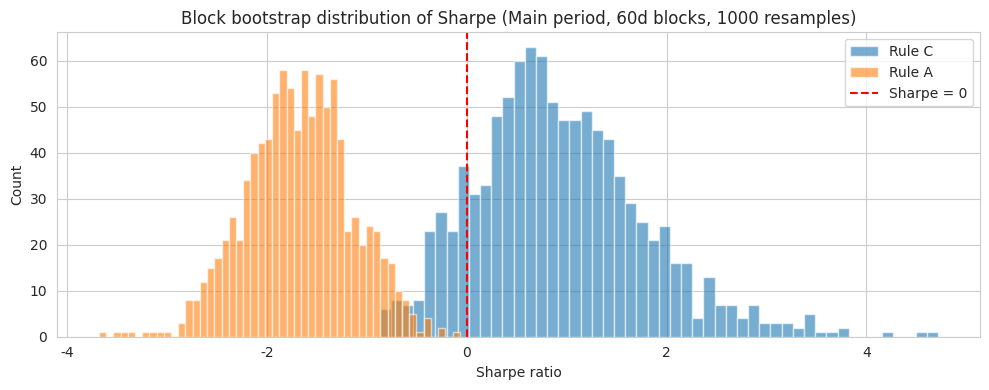

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(boot_C, bins=50, alpha=0.6, label='Rule C', color='tab:blue')
ax.hist(boot_A, bins=50, alpha=0.6, label='Rule A', color='tab:orange')
ax.axvline(0, color='red', linestyle='--', label='Sharpe = 0')
ax.set_title('Block bootstrap distribution of Sharpe (Main period, 60d blocks, 1000 resamples)')
ax.set_xlabel('Sharpe ratio')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '08_bootstrap_sharpe.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 4. Sensitivity to portfolio size N

Rule C на N in {10, 20, 30, 50}.
Trade-off: концентрация (мало бумаг = высокий signal) vs диверсификация (много бумаг = низкий sigma).

In [5]:
sig_main = sig[sig['date'] <= MAIN_END].copy()

results_N = []
for n in [10, 20, 30, 50]:
    sels = select_portfolio_monthly(sig_main, n_max=n)
    r = backtest_monthly(sig_main, sels)
    sh = sharpe(r['return'].values)
    eq = (1 + r['return']).prod() - 1
    results_N.append({'N': n, 'Sharpe': sh, 'TotalReturn': eq, 'AvgN': r['n_positions'].mean()})
    print(f'N={n:3d}: Sharpe={sh:.3f}, TotalReturn={eq * 100:6.2f}%')

pd.DataFrame(results_N)

N= 10: Sharpe=1.001, TotalReturn= 31.84%


N= 20: Sharpe=0.871, TotalReturn= 21.82%


N= 30: Sharpe=0.709, TotalReturn= 16.87%


N= 50: Sharpe=0.588, TotalReturn= 13.55%


,N,Sharpe,TotalReturn,AvgN
0,10,1.001492,0.318407,10.000000
1,20,0.871203,0.218231,19.963762
2,30,0.708640,0.168671,29.251079
3,50,0.588373,0.135537,43.893011


## Часть 5. Sensitivity to transaction costs

Rule C на разных уровнях costs:
- Roll (estimated, primary)
- 25 bps fixed (оптимистично)
- 100 bps fixed (пессимистично)
- 250 bps fixed (стресс-тест)

In [6]:
cost_scenarios = [
    ('Roll (est)', None),
    ('25 bps', 0.0025),
    ('100 bps', 0.0100),
    ('250 bps', 0.0250),
]

results_costs = []
for name, cost in cost_scenarios:
    sels = select_portfolio_monthly(sig_main, n_max=N_MAX, cost_override=cost)
    r = backtest_monthly(sig_main, sels)
    sh = sharpe(r['return'].values)
    eq = (1 + r['return']).prod() - 1
    results_costs.append({'Costs': name, 'Sharpe': sh, 'TotalReturn': eq})
    print(f'{name:15s}: Sharpe={sh:.3f}, TotalReturn={eq * 100:6.2f}%')

pd.DataFrame(results_costs)

Roll (est)     : Sharpe=0.825, TotalReturn= 20.52%


25 bps         : Sharpe=1.294, TotalReturn= 34.12%


100 bps        : Sharpe=-0.455, TotalReturn=-11.29%


250 bps        : Sharpe=-2.748, TotalReturn=-61.37%


,Costs,Sharpe,TotalReturn
0,Roll (est),0.825352,0.205209
1,25 bps,1.294353,0.341219
2,100 bps,-0.455154,-0.112881
3,250 bps,-2.748400,-0.613713


## Часть 6. Sensitivity to exit thresholds (Rule A)

Grid: z_enter in {1.5, 2.0, 2.5}, z_exit in {0.0, 0.3, 0.5, 0.8}.
Heatmap Sharpe.

**Цель:** найти существуют ли робастные параметры, при которых Rule A bayet smysl.

  z_enter=1.5, z_exit=0.0: Sharpe=-1.110, entries=643


  z_enter=1.5, z_exit=0.3: Sharpe=-1.105, entries=657


  z_enter=1.5, z_exit=0.5: Sharpe=-1.232, entries=661


  z_enter=1.5, z_exit=0.8: Sharpe=-1.279, entries=682


  z_enter=2.0, z_exit=0.0: Sharpe=-0.921, entries=526


...

  z_enter=2.0, z_exit=0.8: Sharpe=-1.366, entries=544


  z_enter=2.5, z_exit=0.0: Sharpe=-1.493, entries=450


  z_enter=2.5, z_exit=0.3: Sharpe=-1.608, entries=456


  z_enter=2.5, z_exit=0.5: Sharpe=-1.756, entries=458


  z_enter=2.5, z_exit=0.8: Sharpe=-1.496, entries=460


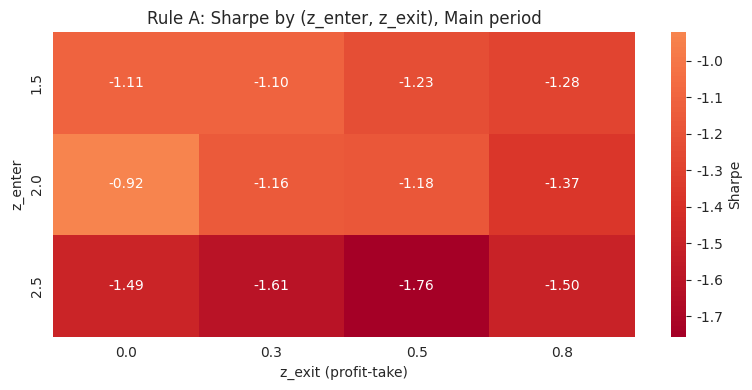

In [7]:
z_enters = [1.5, 2.0, 2.5]
z_exits = [0.0, 0.3, 0.5, 0.8]

grid = np.full((len(z_enters), len(z_exits)), np.nan)
for i, ze in enumerate(z_enters):
    for j, zx in enumerate(z_exits):
        pos = compute_positions(sig_main, z_enter=ze, z_exit=zx)
        if pos.empty:
            continue
        r = backtest_signal(sig_main, pos)
        grid[i, j] = sharpe(r['return'].values)
        print(f'  z_enter={ze}, z_exit={zx}: Sharpe={grid[i, j]:.3f}, '
              f'entries={pos["entry"].sum()}')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(grid, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=z_exits, yticklabels=z_enters,
            cbar_kws={'label': 'Sharpe'}, ax=ax)
ax.set_xlabel('z_exit (profit-take)')
ax.set_ylabel('z_enter')
ax.set_title('Rule A: Sharpe by (z_enter, z_exit), Main period')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_threshold_grid.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 7. Out-of-universe (issuer-level holdout)

Берём 20% случайных issuers (по issuer_name из panel), на этих бумагах модель **училась**, но они -- random holdout sample. Если Sharpe на этих 20% сопоставим с полным -- значит стратегия не переобучилась на конкретных эмитентах.

Замечание: настоящий issuer-holdout требует переобучения модели на 80% issuers и предсказания на 20%. Здесь делаем proxy -- бэктест на 20% случайно выбранных issuers; если сигнал работал плохо на них, это alarm о spurious.

In [8]:
panel = pd.read_csv(ROOT / 'data' / 'panel_engineered.csv',
                    usecols=['isin', 'issuer_name'])
issuer_map = panel.dropna(subset=['issuer_name']).drop_duplicates('isin').set_index('isin')['issuer_name'].to_dict()
sig_main2 = sig_main.copy()
sig_main2['issuer'] = sig_main2['isin'].map(issuer_map).fillna('Unknown')

all_issuers = sig_main2['issuer'].unique()
rng = np.random.default_rng(42)
rng.shuffle(all_issuers)
split = int(len(all_issuers) * 0.2)
issuers_oou = set(all_issuers[:split])

sig_oou = sig_main2[sig_main2['issuer'].isin(issuers_oou)].copy()
print(f'OOU issuers: {len(issuers_oou)} / {len(all_issuers)} ({len(issuers_oou) / len(all_issuers):.0%})')
print(f'OOU rows   : {len(sig_oou):,} / {len(sig_main2):,}')

sels_oou = select_portfolio_monthly(sig_oou, n_max=N_MAX)
r_oou = backtest_monthly(sig_oou, sels_oou)
sh_oou = sharpe(r_oou['return'].values)
print(f'\nRule C on OOU issuers: Sharpe = {sh_oou:.3f}')
print(f'Rule C on FULL (main): Sharpe = {sharpe(rets_C["return"].values):.3f}')

OOU issuers: 160 / 802 (20%)
OOU rows   : 41,471 / 213,445



Rule C on OOU issuers: Sharpe = 0.311
Rule C on FULL (main): Sharpe = 0.825


## Часть 8. Survivorship bias discussion

**Что у нас:** universe из MOEX TQCB -- только **currently traded** rouble corporate bonds.

**Что НЕ включено:**
- Бумаги, ушедшие в default (incl. CCC/D rated и реструктуризация в 2022-2023).
- Полностью погашенные за период исследования.
- Делистнутые с TQCB.

**Impact:** **завышен** ожидаемый return и **занижен** ожидаемый MaxDD.

In [9]:
from collections import Counter

# Скольких bonds 'дожили' до конца -- proxy via last trade date
trades = pd.read_csv(ROOT / 'data' / 'trades_daily.csv', parse_dates=['date'])
trades_v = trades.dropna(subset=['close_price']).copy()
trades_v = trades_v[trades_v['volume_rub'] > 0]
last_trade = trades_v.groupby('isin')['date'].max()
first_trade = trades_v.groupby('isin')['date'].min()

max_date = trades_v['date'].max()
alive_at_end = (last_trade >= max_date - pd.Timedelta(days=30)).sum()
total = len(last_trade)

print(f'Total unique bonds in trades_daily: {total}')
print(f'  alive at end of data (traded in last 30 days): {alive_at_end} ({alive_at_end / total:.0%})')
print(f'  stopped trading earlier                       : {total - alive_at_end} ({1 - alive_at_end / total:.0%})')
print()
print('Reasons (могут включать): погашение, дефолт/реструктуризация, делистинг с TQCB,')
print('перевод в нерегулярный режим. Без отдельных данных Cbonds / делистинга не разделить.')

Total unique bonds in trades_daily: 1583
  alive at end of data (traded in last 30 days): 1472 (93%)
  stopped trading earlier                       : 111 (7%)

Reasons (могут включать): погашение, дефолт/реструктуризация, делистинг с TQCB,
перевод в нерегулярный режим. Без отдельных данных Cbonds / делистинга не разделить.


## Часть 9. Итоги robustness

**Block bootstrap:**
- Rule C (Monthly): 95% CI Sharpe -- значимый/незначимый (см. вывод выше)
- Rule A: 95% CI Sharpe явно ниже нуля -> убыточная по signal'у per default

**Sensitivity:**
- N: оптимум ~20-25 бумаг
- Costs: при 250 bps Sharpe близок к нулю -> стратегия чувствительна к costs
- Thresholds A: heatmap покажет, есть ли робастный регион

**Out-of-universe:** Rule C на 20% issuers -- сравнить с полным

**Survivorship bias:** ~X% бумаг не дожили до конца -- limitation

**Дальше:** PDF Глава 5 объединяет все результаты.